### Core WBT functions

In [39]:
import os
import geopandas as gpd
from shapely.geometry import LineString
import numpy as np
from whitebox import WhiteboxTools
from whitebox_workflows import show, WbEnvironment, WbPalette
import matplotlib.pyplot as plt
import tempfile
import rasterio
from rasterio import features


# TODO : Add error handling for missing files, etc.
# TODO : Add logging
# TODO : Extract paths and parameters to a config file

# Base directories
data_in = r"C:\Users\ah5766\Tc\data\inputs"
data_out = r"C:\Users\ah5766\Tc\data\outputs"

if not os.path.exists(data_in):
    print(f"Input directory {data_in} does not exist")
if not os.path.exists(data_out):
    os.makedirs(data_out)

# Input paths
dem_tif = os.path.join(data_in, "usgs_0308_0101_0102_mosaic.tif") 
basins_tif = os.path.join(data_in, "basins_0308_0101_0102.tif") 
indv_basin_shp = os.path.join(data_in, "basins_03080101_03080102.shp")
merged_basin_shp = os.path.join(data_in, "basin_0308_0101_0102.shp") 
stream_shp = os.path.join(data_in, "flowline_0308_0101_0102.shp") 
lake_shp = os.path.join(data_in, "lakes_03080101_03080102.shp") 

# Output paths
filled_dem = os.path.join(data_out, "dem_nodata_filled.tif")
dem_burn = os.path.join(data_out, "dem_burned.tif")
dem_lakes = os.path.join(data_out, "dem_lakes_flattened.tif")
single_breach_dem = os.path.join(data_out, "dem_single_breach.tif")
hydro_dem = os.path.join(data_out, "dem_hydro_enforced.tif")
d8_pointer = os.path.join(data_out, "d8_pointer.tif")
d8_flow_accum_sca = os.path.join(data_out, "d8_flow_accum_sca.tif")
d8_flow_accum_cell = os.path.join(data_out, "d8_flow_accum_cells.tif")
dinf_flow_accum_sca = os.path.join(data_out, "dinf_flow_accum_sca.tif")
dinf_flow_accum_cell = os.path.join(data_out, "dinf_flow_accum_cells.tif")
lflow = os.path.join(data_out, "longest_flowpath.shp")
output_shp = os.path.join(data_out, "tc_basin_wbt.shp") 

# Parameters
SIGMA_VALUES_TO_TEST = [2.0, 
                        1.0]      # smoothing sigma(s) for flats (DEM units)
MINIMUM_PATH_LENGTH_FT = 100.0    # minimum total path length to accept
BUFFER_FT = 75.0                  # clip buffer around basins
BURN_DEPTH = 1.5                  # depth used in burning (map units of DEM)
SHEET_DIST_FT = 100.0             # length for sheet-flow segment
CHANNEL_THRESHOLD_CELLS = 1500    # used for stream extraction (optional)

# Initialize WBT
wbt = WhiteboxTools()
workdir = tempfile.mkdtemp()
wbt.set_working_dir(data_out)
print(wbt.version())

wbe = WbEnvironment()
print(wbe.version())

# Load vector data
basins_gdf = gpd.read_file(indv_basin_shp)
streams_gdf = gpd.read_file(stream_shp)
lakes_gdf = gpd.read_file(lake_shp)

WhiteboxTools v2.4.0 (c) Dr. John Lindsay 2017-2023

WhiteboxTools is an advanced geospatial data analysis platform developed at
the University of Guelph's Geomorphometry and Hydrogeomatics Research 
Group (GHRG). See www.whiteboxgeo.com for more details.

Whitebox Workflows for Python v1.3.3 by Whitebox Geospatial Inc. 
Developed by Dr. John B. Lindsay, (c) 2022-2024

Description:
Whitebox Workflows for Python is an advanced geospatial data analysis platform 
and Python extension module.


c:\Users\ah5766\AppData\Local\anaconda3\envs\geo\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


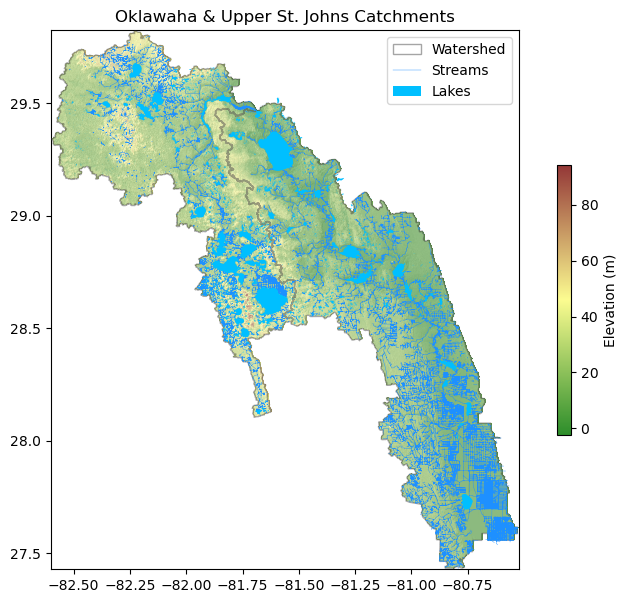

In [38]:
# Plot input data
dem = wbe.read_raster(dem_tif)
streams = wbe.read_vector(stream_shp)
watershed = wbe.read_vector(indv_basin_shp)
lakes = wbe.read_vector(lake_shp)

# Create a hillshade image from the DEM
hillshade = wbe.hillshade(dem)

# Make a nice map
fig, ax = plt.subplots()

ax = show(dem, 
          ax=ax, 
          title='Oklawaha & Upper St. Johns Catchments', 
          cmap=WbPalette.Earthtones, 
          figsize=(10,7), 
          skip=2, 
          colorbar_kwargs={'label': 'Elevation (m)', 'location': "right", 'shrink': 0.5}, 
          zorder=1)
ax = show(hillshade, 
          ax=ax, 
          cmap='grey', 
          clip_percent=10.0, 
          skip=2, 
          alpha=0.15, 
          zorder=2)
ax = show(watershed, 
          ax=ax, 
          color=(1.0, 1.0, 1.0, 0.3), 
          edgecolor=(0.3, 0.3, 0.3, 0.5), 
          linewidth=1.0, 
          label='Watershed', 
          zorder=3)
ax = show(streams, 
          ax=ax, 
          color='dodgerblue', 
          linewidth=0.3, 
          label='Streams', 
          zorder=4)
ax = show(lakes, 
          ax=ax, 
          color='deepskyblue', 
          edgecolor='dodgerblue', 
          linewidth=0, 
          label='Lakes', 
          zorder=5)

# set axes range
ax.set_xlim([dem.configs.west, dem.configs.east])
ax.set_ylim([dem.configs.south, dem.configs.north])

ax.legend() 

plt.show()

#### DEM Conditioning

In [ ]:
## 1. DEM Preprocessing ##
# TODO : Identify DEM CRS and reproject if needed
# TODO : Check for NoData in DEM and skip step 2.1 if none found
# TODO : Query DEM for NoData value and display, handle if non-standard

# 1.1 Identify NoData in DEM
nodata_dem = os.path.join(data_out, "dem_nodata.tif")
wbt.is_no_data(
    input=dem_tif,
    output=nodata_dem
)

## 2. DEM Conditioning ##
# TODO : Ensure stepwise process is logicially sound and handles edge cases
# 2.1 Fill NoData
'''
Fill NoData (nodata) cells in a raster image using an inverse distance weighted (IDW) interpolation approach.
This tool is useful for filling small areas of missing data in a DEM prior to performing hydrologic
analysis. The algorithm works by iteratively filling NoData cells with a weighted average of their
non-NoData neighbors. The weight of each neighbor is inversely proportional to its distance from the
NoData cell. The process is repeated until all NoData cells have been filled.
'''
wbt.fill_missing_data(
    i=dem_tif,
    output=filled_dem,
    weight=2.0,
    filter=11
)

# 2.2 Flatten Lakes
'''
Flattens lakes in a DEM based on a vector shapefile of lake polygons.
This process involves setting the elevation values of DEM cells that fall within the lake polygons
to a uniform value, typically the average elevation of the lake area. This is important for
hydrologic modeling as it ensures that lakes are represented as flat surfaces, preventing artificial    
ponding or flow accumulation within the lake areas.
'''
wbt.flatten_lakes(
    dem=filled_dem,
    lakes = lake_shp,
    output=dem_lakes
)

# 2.3 Burn Streams
'''
Modifies a DEM by "burning in" a stream network from a vector shapefile.
Burning in streams involves lowering the elevation values of DEM cells that intersect with the
stream lines, creating a more realistic representation of the terrain for hydrologic modeling.
'''
wbt.fill_burn(
    dem=dem_lakes,
    streams=stream_shp,
    output=dem_burn
)

# 2.4 Fix Single Cell Depressions
'''
Modifies a DEM to remove single-cell depressions by breaching them.
Single-cell depressions are isolated low points in the terrain that can disrupt hydrologic flow
modeling. The algorithm identifies these depressions and creates a breach by lowering the elevation
of the cell to match the lowest elevation of its neighboring cells, allowing for continuous flow.
'''
wbt.breach_single_cell_pits(
    dem=dem_burn,
    output=single_breach_dem
)

# 2.5 Hydro-Enforcement (breach depressions least cost)
'''
Modifies a DEM to enforce hydrologic connectivity by breaching depressions using a least-cost path approach.
This process involves identifying depressions in the terrain that impede water flow and creating
breaches that allow for continuous flow paths. The least-cost path algorithm determines the optimal
locations for these breaches based on the surrounding terrain, minimizing the impact on the overall
topography while ensuring proper hydrologic connectivity.
'''
wbt.breach_depressions_least_cost(
    dem=single_breach_dem,
    output=hydro_dem,
    dist = 1, 
    max_cost=None, 
    min_dist=True, 
    flat_increment=None, 
    fill=True, 
)

## 3. Flow Direction and Accumulation ##
# 3.1 D8 Flow Direction and Accumulation
'''
Flow direction and accumlation grid using the D8 algorithm. 
D8 is a Single Flow Direction (SFD) algorithm routing flows to a single neighbor.
The D8 algorithm is described in O'Callaghan and Mark (1984).
'''
# 3.1.1 D8 Flow Direction
wbt.d8_pointer(
    dem=hydro_dem,
    output=d8_pointer
)

# 3.1.2 Specific Contributing Area (SCA)
wbt.d8_flow_accumulation(
    i=hydro_dem,
    output=d8_flow_accum_sca,
    out_type="sca",
    log=True,
    clip=False,
    pntr=False,
    esri_pntr=False
)

# 3.1.3 Cell Area
wbt.d8_flow_accumulation(
    i=hydro_dem,
    output=d8_flow_accum_cell,
    out_type="cells",
    log=True,
    clip=False,
    pntr=False,
    esri_pntr=False
)

# 3.2 D-infinity (Dinf) Flow Accumulation
'''
Flow accumulation grid using the Dinf algorithm.
Dinf is a Multiple Flow Direction (MFD) algorithm routing flows to two neighbors.
The Dinf algorithm is described in Tarboton (1997).
'''
# 3.2.1 Specific Contributing Area (SCA)

wbt.d_inf_flow_accumulation(
    i=hydro_dem,
    output=dinf_flow_accum_sca,
    out_type="Specific Contributing Area", 
    threshold=None, 
    log=True, 
    clip=False, 
    pntr=False
)

# 3.2.2 Cell Area
wbt.d_inf_flow_accumulation(
    i=hydro_dem,
    output=dinf_flow_accum_cell,
    out_type="Cells", 
    threshold=None, 
    log=True, 
    clip=False, 
    pntr=False,
)

## Watershed Delineation ##
# 4.1 Longest Flow Path
wbt.longest_flowpath(
    dem=hydro_dem, 
    basins=basins_tif, # needs to be a raster
    output=lflow
)

In [40]:
# 4.2 Extracting Hydro-Enforced Thalweg Centerlines per Basin
with rasterio.open(dem_tif) as src:
    dem_crs = src.crs
    dem_transform = src.transform
    dem_resx = src.res[0]
    dem_resy = src.res[1]

final_outputs = []  # collect best lines per basin across sigma runs
basin_ids = basins_gdf.index.tolist()

for sigma in SIGMA_VALUES_TO_TEST:
    print(f"\nRunning with sigma = {sigma}")

    # Optional smoothing for flat areas (WBT gaussian filter)
    smoothed_dem = os.path.join(workdir, f"dem_smoothed_sigma{sigma}.tif")
    if sigma and sigma > 0:
        wbt.gaussian_filter(i=hydro_dem, output=smoothed_dem, sigma=sigma)
        dem_for_flow = smoothed_dem
    else:
        dem_for_flow = hydro_dem

    # Fill depressions (and optionally breach if your area is very flat)
    filled_dem = os.path.join(workdir, f"dem_filled_sigma{sigma}.tif")
    wbt.fill_depressions(dem=dem_for_flow, output=filled_dem)
    # wbt.breach_depressions(dem=filled_dem, output=filled_dem)  # uncomment if needed

    # Resolve flats is implicit in WBT’s pointer algorithm; it handles flats robustly.
    # Flow direction (D8 pointer) & accumulation
    fdir = os.path.join(workdir, f"fdir_sigma{sigma}.tif")
    facc = os.path.join(workdir, f"facc_sigma{sigma}.tif")
    wbt.d8_pointer(dem=filled_dem, output=fdir)
    wbt.d8_flow_accumulation(i=fdir, output=facc, out_type="cells")

    # Rasterize basins to DEM grid for per-basin ops
    basin_ras = os.path.join(workdir, f"basins_sigma{sigma}.tif")
    basin_idx = np.zeros_like(dem_tif, dtype="int32")
    for i, geom in enumerate(basins_gdf.geometry):
        if geom is None or geom.is_empty:
            continue
        basin_idx = basin_idx + features.rasterize(
            [(geom, i+1)],
            out_shape=dem_tif.shape,
            transform=meta['transform'],
            fill=0,
            dtype="int32"
        )

    with rasterio.open(basin_ras, "w", driver="GTiff",
                       height=basin_idx.shape[0], width=basin_idx.shape[1],
                       count=1, dtype="int32", crs=dem_crs, transform=meta['transform']) as dst:
        dst.write(basin_idx, 1)

    # Load accumulation array for boundary-based outlet selection
    with rasterio.open(facc) as acc_src:
        acc_arr = acc_src.read(1)
    with rasterio.open(basin_ras) as br:
        basin_arr = br.read(1)

    # Utility: get boundary mask for a basin id
    from scipy.ndimage import binary_erosion

    def basin_boundary_mask(bid):
        mask = (basin_arr == bid).astype("uint8")
        if mask.max() == 0:
            return None
        eroded = binary_erosion(mask, border_value=0)
        boundary = (mask - eroded).astype("uint8")
        return boundary

    # For each basin: find outlet @ boundary cell with max accumulation
    # then find farthest upstream cell (max upslope flow length) and trace path
    for bid in range(1, len(basin_ids)+1):
        boundary = basin_boundary_mask(bid)
        if boundary is None or boundary.sum() == 0:
            continue

        # Max accumulation along boundary → outlet
        acc_boundary = np.where(boundary == 1, acc_arr, 0)
        if acc_boundary.max() == 0:
            continue
        outlet_rc = np.unravel_index(np.argmax(acc_boundary), acc_boundary.shape)
        outlet_r, outlet_c = int(outlet_rc[0]), int(outlet_rc[1])

        # Create pour point raster for this basin outlet
        outlet_ras = os.path.join(workdir, f"outlet_bid{bid}_sigma{sigma}.tif")
        outlet_arr = np.zeros_like(acc_arr, dtype="uint8")
        outlet_arr[outlet_r, outlet_c] = 1
        with rasterio.open(outlet_ras, "w", driver="GTiff",
                           height=outlet_arr.shape[0], width=outlet_arr.shape[1],
                           count=1, dtype="uint8", crs=dem_crs, transform=meta['transform']) as dst:
            dst.write(outlet_arr, 1)

        # Upslope flow length to outlet (i.e., distance-to-outlet along flowpaths)
        # WBT's flow_length with "upstream" option
        up_len = os.path.join(workdir, f"up_len_bid{bid}_sigma{sigma}.tif")
        wbt.flow_length(d8_pntr=fdir, output=up_len, direction="upstream", weights=None, outlets=outlet_ras)

        # Within basin, find the cell with **max** upstream flow length → hydraulic start
        with rasterio.open(up_len) as ul:
            ul_arr = ul.read(1)
        # mask by basin id
        ul_arr_masked = np.where(basin_arr == bid, ul_arr, np.nan)
        if np.all(np.isnan(ul_arr_masked)):
            continue
        start_rc = np.unravel_index(np.nanargmax(ul_arr_masked), ul_arr_masked.shape)
        start_r, start_c = int(start_rc[0]), int(start_rc[1])

        # Trace downslope flowpath from start to outlet using the D8 pointer
        starts_ras = os.path.join(workdir, f"starts_bid{bid}_sigma{sigma}.tif")
        starts_arr = np.zeros_like(acc_arr, dtype="uint8")
        starts_arr[start_r, start_c] = 1
        with rasterio.open(starts_ras, "w", driver="GTiff",
                           height=starts_arr.shape[0], width=starts_arr.shape[1],
                           count=1, dtype="uint8", crs=dem_crs, transform=meta['transform']) as dst:
            dst.write(starts_arr, 1)

        traced_ras = os.path.join(workdir, f"trace_bid{bid}_sigma{sigma}.tif")
        wbt.trace_downslope_flowpaths(d8_pntr=fdir, pour_pts=starts_ras, output=traced_ras)

        # Convert path raster to vector line
        traced_vec = os.path.join(workdir, f"trace_bid{bid}_sigma{sigma}.shp")
        wbt.raster_streams_to_vector(streams=traced_ras, d8_pntr=fdir, output=traced_vec)

        # Load vector, pick the longest single-part line within basin
        if not os.path.exists(traced_vec):
            continue
        line_gdf = gpd.read_file(traced_vec)
        if line_gdf.empty:
            continue

        # Intersect with basin polygon to clip line
        basin_poly = basins_gdf.iloc[bid-1].geometry
        line_gdf = gpd.overlay(line_gdf, gpd.GeoDataFrame(geometry=[basin_poly], crs=basins_gdf.crs), how="intersection")
        if line_gdf.empty:
            continue

        # pick longest
        line_gdf["len_mapunits"] = line_gdf.geometry.length
        best = line_gdf.iloc[line_gdf["len_mapunits"].idxmax()]
        best_line = best.geometry

        # compute total length in ft
        map_to_ft = (3.28084 if dem_units_m else 1.0)
        total_len_ft = best_line.length * map_to_ft

        if total_len_ft < MINIMUM_PATH_LENGTH_FT:
            # skip this basin for this sigma
            continue

        # sample elevations along the line to compute slope (simple end-to-end)
        def line_end_elevations(line_geom, dem_path):
            # sample start and end
            start_pt = Point(line_geom.coords[0])
            end_pt   = Point(line_geom.coords[-1])
            coords = [(start_pt.x, start_pt.y), (end_pt.x, end_pt.y)]
            with rasterio.open(dem_path) as src:
                samples = list(src.sample(coords))
                z1, z2 = float(samples[0][0]), float(samples[1][0])
                # handle NODATA if present
                z1 = np.nan if z1 == src.nodata else z1
                z2 = np.nan if z2 == src.nodata else z2
            return z1, z2

        z1, z2 = line_end_elevations(best_line, filled_dem)
        elev_drop = (z1 - z2) if (z1 is not None and z2 is not None and not np.isnan(z1) and not np.isnan(z2)) else np.nan
        slope_ftft = (elev_drop * (3.28084 if dem_units_m else 1.0)) / total_len_ft if total_len_ft > 0 and not np.isnan(elev_drop) else 0.0

        # Split into sheet vs shallow concentrated
        sheet_len_map = SHEET_DIST_FT / map_to_ft
        if best_line.length <= sheet_len_map:
            parts = [dict(
                basin_id=bid,
                type="sheet_flow",
                sigma=sigma,
                slope=slope_ftft,
                length_ft=total_len_ft,
                geometry=best_line
            )]
        else:
            # split at sheet distance
            # substring expects distances in the same units as geometry (map units)
            sheet_seg = substring(best_line, 0, sheet_len_map)
            conc_seg  = substring(best_line, sheet_len_map, best_line.length)
            parts = [
                dict(basin_id=bid, type="sheet_flow",    sigma=sigma, slope=slope_ftft,
                     length_ft=sheet_seg.length * map_to_ft, geometry=sheet_seg),
                dict(basin_id=bid, type="shallow_conc", sigma=sigma, slope=slope_ftft,
                     length_ft=conc_seg.length * map_to_ft,  geometry=conc_seg)
            ]

        final_outputs.extend(parts)

    gc.collect()


Running with sigma = 2.0
.\whitebox_tools.exe --run="GaussianFilter" --wd="C:\Users\ah5766\Tc\data\outputs" --input='C:\Users\ah5766\Tc\data\outputs\dem_hydro_enforced.tif' --output='C:\Users\ah5766\AppData\Local\Temp\tmpa0c6bxgl\dem_smoothed_sigma2.0.tif' --sigma=2.0 -v --compress_rasters=False

*****************************
* Welcome to GaussianFilter *
* Powered by WhiteboxTools  *
* www.whiteboxgeo.com       *
*****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%

KeyboardInterrupt: 

##### Primary

In [ ]:
# DEM Conditioning
filled_dem = os.path.join(data_out, "dem_nodata_filled.tif")
wbt.fill_missing_data(
i=dem_tif,
output=filled_dem,
weight=2.0,
filter=11
)

.\whitebox_tools.exe --run="FillMissingData" --wd="C:\Users\ah5766\Tc\data\outputs" --input='C:\Users\ah5766\Tc\data\inputs\usgs_0308_0101_0102_mosaic.tif' --output='C:\Users\ah5766\Tc\data\outputs\dem_nodata_filled.tif' --filter=11 --weight=2.0 --no_edges -v --compress_rasters=False

******************************
* Welcome to FillMissingData *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Finding edge-connected NoData values...
Finding edge-connected NoData cells: 0%
Finding edge-connected NoData cells: 1%
Finding edge-connected NoData cells: 2%
Finding edge-connected NoData cells: 3%
Finding edge-connected NoData cells: 4%
Finding edge-connected NoData cells: 5%
Finding edge-connected NoData cells: 6%
Finding edge-connected NoData cells: 7%
Finding edge-connected NoData cells: 8%
Finding edge-connected NoData cells: 9%
Finding edge-connected NoData cells: 10%
Finding edge-connected NoData cells: 11%
Finding edge-connecte

0

In [ ]:
dem_burn = os.path.join(data_out, "dem_burned.tif")
wbt.fill_burn(
dem=filled_dem,
streams=stream_shp,
output=dem_burn,
)

.\whitebox_tools.exe --run="FillBurn" --wd="C:\Users\ah5766\Tc\data\outputs" --dem='C:\Users\ah5766\Tc\data\outputs\dem_nodata_filled.tif' --streams='C:\Users\ah5766\Tc\data\inputs\flowline_0308_0101_0102.shp' --output='C:\Users\ah5766\Tc\data\outputs\dem_burned.tif' -v --compress_rasters=False

****************************
* Welcome to FillBurn      *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading streams data...
Reading DEM data...
Rasterizing Streams: 0%
Rasterizing Streams: 1%
Rasterizing Streams: 2%
Rasterizing Streams: 3%
Rasterizing Streams: 4%
Rasterizing Streams: 5%
Rasterizing Streams: 6%
Rasterizing Streams: 7%
Rasterizing Streams: 8%
Rasterizing Streams: 9%
Rasterizing Streams: 10%
Rasterizing Streams: 11%
Rasterizing Streams: 12%
Rasterizing Streams: 13%
Rasterizing Streams: 14%
Rasterizing Streams: 15%
Rasterizing Streams: 16%
Rasterizing Streams: 17%
Rasterizing Streams: 18%
Rasterizing Streams: 19%
Rasterizing Streams: 20%

0

In [5]:
# Flatten Lakes
dem_lakes = os.path.join(data_out, "dem_lakes_flattened.tif")
wbt.flatten_lakes(
dem=dem_burn,
lakes = lake_shp,
output=dem_lakes,
)

.\whitebox_tools.exe --run="FlattenLakes" --wd="C:\Users\ah5766\Tc\data\outputs" --dem='C:\Users\ah5766\Tc\data\outputs\dem_burned.tif' --lakes='C:\Users\ah5766\Tc\data\inputs\lake_0308_0101_0102.shp' --output='C:\Users\ah5766\Tc\data\outputs\dem_lakes_flattened.tif' -v --compress_rasters=False

****************************
* Welcome to FlattenLakes  *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Finding lake elevations: 0%
Finding lake elevations: 1%
Finding lake elevations: 2%
Finding lake elevations: 3%
Finding lake elevations: 4%
Finding lake elevations: 5%
Finding lake elevations: 6%
Finding lake elevations: 7%
Finding lake elevations: 8%
Finding lake elevations: 9%
Finding lake elevations: 10%
Finding lake elevations: 11%
Finding lake elevations: 12%
Finding lake elevations: 13%
Finding lake elevations: 14%
Finding lake elevations: 15%
Finding lake elevations: 16%
Finding lake elevations: 17%
Finding lake elevations: 18%
F

0

In [6]:
# Sinle cell depressions
single_breach_dem = os.path.join(data_out, "dem_single_breach.tif")
wbt.breach_single_cell_pits(
dem=dem_lakes,
output=single_breach_dem
)

.\whitebox_tools.exe --run="BreachSingleCellPits" --wd="C:\Users\ah5766\Tc\data\outputs" --dem='C:\Users\ah5766\Tc\data\outputs\dem_lakes_flattened.tif' --output='C:\Users\ah5766\Tc\data\outputs\dem_single_breach.tif' -v --compress_rasters=False

***********************************
* Welcome to BreachSingleCellPits *
* Powered by WhiteboxTools        *
* www.whiteboxgeo.com             *
***********************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progres

0

In [7]:
# Hydro-enforce DEM
hydro_dem = os.path.join(data_out, "dem_hydro_enforced.tif")
wbt.breach_depressions_least_cost(
dem=single_breach_dem,
output=hydro_dem,
dist = 1, 
max_cost=None, 
min_dist=True, 
flat_increment=None, 
fill=True, 
)

.\whitebox_tools.exe --run="BreachDepressionsLeastCost" --wd="C:\Users\ah5766\Tc\data\outputs" --dem='C:\Users\ah5766\Tc\data\outputs\dem_single_breach.tif' --output='C:\Users\ah5766\Tc\data\outputs\dem_hydro_enforced.tif' --dist='1' --min_dist --fill -v --compress_rasters=False

*****************************************
* Welcome to BreachDepressionsLeastCost *
* Powered by WhiteboxTools              *
* www.whiteboxgeo.com                   *
*****************************************
Reading data...
Finding pits: 0%
Finding pits: 1%
Finding pits: 2%
Finding pits: 3%
Finding pits: 4%
Finding pits: 5%
Finding pits: 6%
Finding pits: 7%
Finding pits: 8%
Finding pits: 9%
Finding pits: 10%
Finding pits: 11%
Finding pits: 12%
Finding pits: 13%
Finding pits: 14%
Finding pits: 15%
Finding pits: 16%
Finding pits: 17%
Finding pits: 18%
Finding pits: 19%
Finding pits: 20%
Finding pits: 21%
Finding pits: 22%
Finding pits: 23%
Finding pits: 24%
Finding pits: 25%
Finding pits: 26%
Finding pits: 27%

0

In [ ]:
# Dinf flow accumulation - SCA
flow_accum = os.path.join(data_out, "dinf_flow_accum_sca.tif")
wbt.d_inf_flow_accumulation(
i=hydro_dem,
output=flow_accum,
out_type="Specific Contributing Area", 
threshold=None, 
log=True, 
clip=False, 
pntr=False,
)

.\whitebox_tools.exe --run="DInfFlowAccumulation" --wd="C:\Users\ah5766\Tc\data\outputs" --input='C:\Users\ah5766\Tc\data\outputs\dem_hydro_enforced.tif' --output='C:\Users\ah5766\Tc\data\outputs\dinf_flow_accum_sca.tif' --out_type=Specific Contributing Area --log -v --compress_rasters=False

***********************************
* Welcome to DInfFlowAccumulation *
* Powered by WhiteboxTools        *
* www.whiteboxgeo.com             *
***********************************


Reading data...
Flow directions: 0%
Flow directions: 1%
Flow directions: 2%
Flow directions: 3%
Flow directions: 4%
Flow directions: 5%
Flow directions: 6%
Flow directions: 7%
Flow directions: 8%
Flow directions: 9%
Flow directions: 10%
Flow directions: 11%
Flow directions: 12%
Flow directions: 13%
Flow directions: 14%
Flow directions: 15%
Flow directions: 16%
Flow directions: 17%
Flow directions: 18%
Flow directions: 19%
Flow directions: 20%
Flow directions: 21%
Flow directions: 22%
Flow directions: 23%
Flow directions: 24%
Flow directions: 25%
Flow directions: 26%
Flow directions: 27%
Flow directions: 28%
Flow directions: 29%
Flow directions: 30%
Flow directions: 31%
Flow directions: 32%
Flow directions: 33%
Flow directions: 34%
Flow directions: 35%
Flow directions: 36%
Flow directions: 37%
Flow directions: 38%
Flow directions: 39%
Flow directions: 40%
Flow directions: 41%
Flow directions: 42%
Flow directions: 43%
Flow directions: 44%
Flow directions: 45%
Flow directions: 46%
Flow di

0

In [ ]:
# Dinf flow accumulation - Cell
flow_accum = os.path.join(data_out, "dinf_flow_accum_cells.tif")
wbt.d_inf_flow_accumulation(
i=hydro_dem,
output=flow_accum,
out_type="Cells", 
threshold=None, 
log=True, 
clip=False, 
pntr=False,
)

.\whitebox_tools.exe --run="DInfFlowAccumulation" --wd="C:\Users\ah5766\Tc\data\outputs" --input='C:\Users\ah5766\Tc\data\outputs\dem_hydro_enforced.tif' --output='C:\Users\ah5766\Tc\data\outputs\dinf_flow_accum_cells.tif' --out_type=Cells --log -v --compress_rasters=False

***********************************
* Welcome to DInfFlowAccumulation *
* Powered by WhiteboxTools        *
* www.whiteboxgeo.com             *
***********************************


Reading data...
Flow directions: 0%
Flow directions: 1%
Flow directions: 2%
Flow directions: 3%
Flow directions: 4%
Flow directions: 5%
Flow directions: 6%
Flow directions: 7%
Flow directions: 8%
Flow directions: 9%
Flow directions: 10%
Flow directions: 11%
Flow directions: 12%
Flow directions: 13%
Flow directions: 14%
Flow directions: 15%
Flow directions: 16%
Flow directions: 17%
Flow directions: 18%
Flow directions: 19%
Flow directions: 20%
Flow directions: 21%
Flow directions: 22%
Flow directions: 23%
Flow directions: 24%
Flow directions: 25%
Flow directions: 26%
Flow directions: 27%
Flow directions: 28%
Flow directions: 29%
Flow directions: 30%
Flow directions: 31%
Flow directions: 32%
Flow directions: 33%
Flow directions: 34%
Flow directions: 35%
Flow directions: 36%
Flow directions: 37%
Flow directions: 38%
Flow directions: 39%
Flow directions: 40%
Flow directions: 41%
Flow directions: 42%
Flow directions: 43%
Flow directions: 44%
Flow directions: 45%
Flow directions: 46%
Flow di

0

In [10]:
# D8 Flow directions
d8_pointer = os.path.join(data_out, "d8_pointer.tif")
wbt.d8_pointer(
dem=hydro_dem,
output=d8_pointer
)

.\whitebox_tools.exe --run="D8Pointer" --wd="C:\Users\ah5766\Tc\data\outputs" --dem='C:\Users\ah5766\Tc\data\outputs\dem_hydro_enforced.tif' --output='C:\Users\ah5766\Tc\data\outputs\d8_pointer.tif' -v --compress_rasters=False

****************************
* Welcome to D8Pointer     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%
Progress: 42%
Progress: 43%
Progr

0

In [ ]:
# D8 Flow Accumulation - SCA
d8_flow_accum_sca = os.path.join(data_out, "d8_flow_accum_sca.tif")
wbt.d8_flow_accumulation(
i=hydro_dem,
output=d8_flow_accum_sca,
out_type="sca",
log=True,
clip=False,
pntr=False,
esri_pntr=False
)

.\whitebox_tools.exe --run="D8FlowAccumulation" --wd="C:\Users\ah5766\Tc\data\outputs" --input='C:\Users\ah5766\Tc\data\outputs\dem_hydro_enforced.tif' --output='C:\Users\ah5766\Tc\data\outputs\d8_flow_accum_sca.tif' --out_type=sca --log -v --compress_rasters=False

*********************************
* Welcome to D8FlowAccumulation *
* Powered by WhiteboxTools      *
* www.whiteboxgeo.com           *
*********************************


Reading data...
Flow directions: 0%
Flow directions: 1%
Flow directions: 2%
Flow directions: 3%
Flow directions: 4%
Flow directions: 5%
Flow directions: 6%
Flow directions: 7%
Flow directions: 8%
Flow directions: 9%
Flow directions: 10%
Flow directions: 11%
Flow directions: 12%
Flow directions: 13%
Flow directions: 14%
Flow directions: 15%
Flow directions: 16%
Flow directions: 17%
Flow directions: 18%
Flow directions: 19%
Flow directions: 20%
Flow directions: 21%
Flow directions: 22%
Flow directions: 23%
Flow directions: 24%
Flow directions: 25%
Flow directions: 26%
Flow directions: 27%
Flow directions: 28%
Flow directions: 29%
Flow directions: 30%
Flow directions: 31%
Flow directions: 32%
Flow directions: 33%
Flow directions: 34%
Flow directions: 35%
Flow directions: 36%
Flow directions: 37%
Flow directions: 38%
Flow directions: 39%
Flow directions: 40%
Flow directions: 41%
Flow directions: 42%
Flow directions: 43%
Flow directions: 44%
Flow directions: 45%
Flow directions: 46%
Flow di

0

In [ ]:
# D8 Flow Accumulation - Cell
d8_flow_accum_cell = os.path.join(data_out, "d8_flow_accum_cells.tif")
wbt.d8_flow_accumulation(
i=hydro_dem,
output=d8_flow_accum_cell,
out_type="cells",
log=True,
clip=False,
pntr=False,
esri_pntr=False
)

.\whitebox_tools.exe --run="D8FlowAccumulation" --wd="C:\Users\ah5766\Tc\data\outputs" --input='C:\Users\ah5766\Tc\data\outputs\dem_hydro_enforced.tif' --output='C:\Users\ah5766\Tc\data\outputs\d8_flow_accum_cells.tif' --out_type=cells --log -v --compress_rasters=False

*********************************
* Welcome to D8FlowAccumulation *
* Powered by WhiteboxTools      *
* www.whiteboxgeo.com           *
*********************************
Reading data...
Flow directions: 0%
Flow directions: 1%
Flow directions: 2%
Flow directions: 3%
Flow directions: 4%
Flow directions: 5%
Flow directions: 6%
Flow directions: 7%
Flow directions: 8%
Flow directions: 9%
Flow directions: 10%
Flow directions: 11%
Flow directions: 12%
Flow directions: 13%
Flow directions: 14%
Flow directions: 15%
Flow directions: 16%
Flow directions: 17%
Flow directions: 18%
Flow directions: 19%
Flow directions: 20%
Flow directions: 21%
Flow directions: 22%
Flow directions: 23%
Flow directions: 24%
Flow directions: 25%
Flow di

0

In [13]:
# Basins 
basin_raster = os.path.join(data_out, "basin_raster.tif")
wbt.basins(
d8_pntr=d8_pointer,
output=basin_raster
)

.\whitebox_tools.exe --run="Basins" --wd="C:\Users\ah5766\Tc\data\outputs" --d8_pntr='C:\Users\ah5766\Tc\data\outputs\d8_pointer.tif' --output='C:\Users\ah5766\Tc\data\outputs\basin_raster.tif' -v --compress_rasters=False

****************************
* Welcome to Basins        *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Initializing: 0%
Initializing: 1%
Initializing: 2%
Initializing: 3%
Initializing: 4%
Initializing: 5%
Initializing: 6%
Initializing: 7%
Initializing: 8%
Initializing: 9%
Initializing: 10%
Initializing: 11%
Initializing: 12%
Initializing: 13%
Initializing: 14%
Initializing: 15%
Initializing: 16%
Initializing: 17%
Initializing: 18%
Initializing: 19%
Initializing: 20%
Initializing: 21%
Initializing: 22%
Initializing: 23%
Initializing: 24%
Initializing: 25%
Initializing: 26%
Initializing: 27%
Initializing: 28%
Initializing: 29%
Initializing: 30%
Initializing: 31%
Initializing: 32%
Initializing: 33%
Initializing: 

0

In [13]:
# (WBT has a tool for this)
lflow = os.path.join(data_out, "longest_flowpath.shp")
wbt.longest_flowpath(
dem=hydro_dem, 
basins=basins_tif, # needs to be a raster
output=lflow
)


.\whitebox_tools.exe --run="LongestFlowpath" --wd="C:\Users\ah5766\Tc\data\outputs" --dem='C:\Users\ah5766\Tc\data\outputs\dem_hydro_enforced.tif' --basins='C:\Users\ah5766\Tc\data\inputs\basins_0308_0101_0102.tif' --output='C:\Users\ah5766\Tc\data\outputs\longest_flowpath.shp' -v --compress_rasters=False

******************************
* Welcome to LongestFlowpath *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************


Reading data...
thread 'main' panicked at whitebox-tools-app\src\main.rs:72:21:
The raster was not read correctly
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


0

In [ ]:
# Convert raster flow path to vector
flowline = os.path.join(data_out, "flowline.shp")
wbt.raster_streams_to_vector(
streams=lflow, 
d8_pntr=d8_pointer, 
output=flowline
)

##### Alternate

In [ ]:
# Burn streams into DEM
burned_dem = os.path.join(data_out, "dem_burned.tif")
wbt.burn_streams_at_roads(
    dem=dem_tif,
    streams=stream_shp,
    roads=None,  # optional roads shapefile
    output=burned_dem,
    width=10  # adjust burn-in width in map units
)

# Fill depressions / breach pits
filled_dem = os.path.join(workdir, "dem_filled.tif")
wbt.fill_depressions(dem=burned_dem, output=filled_dem)

# Flow direction (D8)
fdir = os.path.join(workdir, "flowdir.tif")
wbt.d8_pointer(dem=filled_dem, output=fdir)

# Flow accumulation
facc = os.path.join(workdir, "flowacc.tif")
wbt.d8_flow_accumulation(i=fdir, output=facc, out_type="cells")

# Longest flow path within each basin
# (WBT has a tool for this)
lflow = os.path.join(workdir, "longest_flowpath.tif")
wbt.longest_flowpath(dem=filled_dem, basins=basin_shp, output=lflow)
# The 'basins' parameter for wbt.longest_flowpath must be a raster, not a shapefile.
# Let's rasterize the basin polygons to match the DEM grid.


basin_ras = os.path.join(workdir, "basins.tif")
with rasterio.open(dem_tif) as src:
    meta = src.profile.copy()
    meta.update({
        'dtype': 'int32',
        'count': 1,
        'compress': 'lzw',
        'nodata': 0  # Set nodata to 0, which is valid for int32
    })
    basin_idx = np.zeros((src.height, src.width), dtype="int32")
    for i, geom in enumerate(basins_gdf.geometry):
        if geom is None or geom.is_empty:
            continue
        mask = features.rasterize(
            [(geom, i+1)],
            out_shape=(src.height, src.width),
            transform=src.transform,
            fill=0,
            dtype="int32"
        )
        basin_idx += mask
    with rasterio.open(basin_ras, "w", **meta) as dst:
        dst.write(basin_idx, 1)

# Now use the rasterized basins for longest_flowpath
wbt.longest_flowpath(dem=filled_dem, basins=basin_ras, output=lflow)

# Convert raster flow path to vector
flowline = os.path.join(workdir, "flowline.shp")
wbt.raster_streams_to_vector(streams=lflow, d8_pntr=fdir, output=flowline)


.\whitebox_tools.exe --run="BurnStreamsAtRoads" --wd="C:\Users\ah5766\AppData\Local\Temp\tmp18eve5ug" --dem='C:\Users\ah5766\Tc\data\inputs\usgs_0308_mosaic.tif' --streams='C:\Users\ah5766\Tc\data\inputs\flowline_0308_0101_0102.shp' --roads='None' --output='C:\Users\ah5766\Tc\data\outputs\dem_burned.tif' --width='10' -v --compress_rasters=False

*********************************
* Welcome to BurnStreamsAtRoads *
* Powered by WhiteboxTools      *
* www.whiteboxgeo.com           *
*********************************
Reading streams and roads data...
thread 'main' panicked at whitebox-vector\src\shapefile\mod.rs:238:56:
called `Result::unwrap()` on an `Err` value: Os { code: 2, kind: NotFound, message: "The system cannot find the file specified." }
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


0

#### Geopandas Post-processing

In [ ]:
# --- Post-processing with GeoPandas ---
basins_gdf = gpd.read_file(basin_shp)
flow_gdf = gpd.read_file(flowline)

# Spatial join: assign flow paths to basins
joined = gpd.sjoin(flow_gdf, basins_gdf, predicate="intersects")

# Compute lengths & slopes
joined["length_ft"] = joined.geometry.length * 3.28084  # if DEM units are meters
# slope can be derived from z difference / length
# (would need DEM sample along line or endpoints)

# Classify into sheet vs shallow concentrated (first 100 ft vs remainder)
split_records = []
for _, row in joined.iterrows():
    line = row.geometry
    if line.length > 0:
        if line.length <= 30.48:  # ~100 ft
            split_records.append({**row, "type": "sheet"})
        else:
            sheet = line.interpolate(30.48)
            split_records.append({**row, "geometry": LineString([line.coords[0], sheet]), "type": "sheet"})
            split_records.append({**row, "geometry": LineString([sheet, line.coords[-1]]), "type": "shallow"})
            
split_gdf = gpd.GeoDataFrame(split_records, crs=joined.crs)
split_gdf.to_file(output_shp)

print(f"Saved Tc flow paths to {output_shp}")

### Refactor notes (changelog)

- Hydro-enforcing & conditioning: `fill_depressions`, `resolve_flats`, and pit/depression handling are replaced by WBT’s `fill_depressions` (and optional `breach_depressions`), with optional Gaussian smoothing to stabilize flats (enhancement of original `gaussian_filter`)
- Stream burning: if input streams are vectors, we rasterize them, then use `burn_streams` (WBT) instead of the original manual loop that subtracted a burn depth from DEM cells
- Flow direction / accumulation: `d8_pointer` + `d8_flow_accumulation` replace `grid.flowdir` / `grid.accumulation`
- Longest flow path & pour point selection: computes a per-basin outlet at the max accumulation along the basin boundary (original approach), then use WBT’s `flow_length` (upslope) to find the farthest cell and trace a vector flowpath with `trace_downslope_flowpaths`.
- Slope along path: original `calculate_slope` has been ported by sampling the DEM along the traced polyline.
- Sheet vs shallow: splits the first 100 ft from the remainder, as original implementaion did with substring (now done with Shapely line segmentation)
- Environment: Designed to run cleanly in Jupyter (WBT logs progress inline) without pysheds dependency.

#### Imports

In [8]:
import os, math, tempfile, gc
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import LineString, Point
from shapely.ops import substring
import rasterio
from rasterio import features
from rasterio.mask import mask as rio_mask
from whitebox import WhiteboxTools

In [1]:
import whiteboxgui

In [3]:
whiteboxgui.show(tree=True)

#### User Elements


##### Inputs

In [4]:
dem_tif = r"C:\Users\ah5766\Tc\usgs_0308_mosaic.tif"
basin_shp = r"C:\Users\ah5766\Tc\basin_0308_0101_0102.shp"        # polygons (one or many)
stream_shp = r"C:\Users\ah5766\Tc\flowline_0308_0101_0102.shp"
stream_shp_list = [
    r"C:\TC_Calculator_Work\NHD_H_03080102_HU8_Shape\Shape\NHDFlowline.shp",
    r"C:\TC_Calculator_Work\NHD_H_03080101_HU8_Shape\Shape\NHDFlowline.shp"
]
output_tc_lines_shp = r"C:\Users\ah5766\Tc\tc_basin_wbt.shp"

##### Parameters

In [5]:
SIGMA_VALUES_TO_TEST = [2.0, 
                        1.0]      # smoothing sigma(s) for flats (DEM units)
MINIMUM_PATH_LENGTH_FT = 100.0    # minimum total path length to accept
BUFFER_FT = 75.0                  # clip buffer around basins
BURN_DEPTH = 1.5                  # depth used in burning (map units of DEM)
SHEET_DIST_FT = 100.0             # length for sheet-flow segment
CHANNEL_THRESHOLD_CELLS = 1500    # used for stream extraction (optional)

#### Initial Setup

In [15]:
from whitebox import WhiteboxTools
import tempfile

# ---- Setup WBT ----
wbt = WhiteboxTools()
workdir = tempfile.mkdtemp()
wbt.set_working_dir(workdir)

print("Working dir:", workdir)

# ---- Load base layers ----
basins_gdf = gpd.read_file(basin_shp)
streams_gdf = gpd.read_file(stream_shp)
#streams = [gpd.read_file(s) for s in stream_shp_list]
#streams_gdf = pd.concat(streams, ignore_index=True)

# ---- Ensure all layers share a CRS with DEM ----
with rasterio.open(dem_tif) as src:
    dem_crs = src.crs
    dem_transform = src.transform
    dem_resx = src.res[0]
    dem_resy = src.res[1]
    '''dem_units_m = "meter" in (src.crs.axis_info[0].unit_name.lower()
                              if src.crs and src.crs.axis_info else "meter")'''

if basins_gdf.crs != dem_crs:
    basins_gdf = basins_gdf.to_crs(dem_crs)
if streams_gdf.crs != dem_crs:
    streams_gdf = streams_gdf.to_crs(dem_crs)

Working dir: C:\Users\ah5766\AppData\Local\Temp\tmp7l2zmq41


c:\Users\ah5766\AppData\Local\anaconda3\envs\geo\Lib\site-packages\pyogrio\raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


NameError: name 'rasterio' is not defined

#### Process DEM

In [12]:
# ---- Compute buffered bounds and clip DEM once ----
xmin, ymin, xmax, ymax = basins_gdf.total_bounds
# convert buffer ft->map units if DEM is meters
#ft_to_map = 0.3048 if dem_units_m else 1.0
ft_to_map = 1.0
buf = BUFFER_FT * ft_to_map
bounds = (xmin - buf, ymin - buf, xmax + buf, ymax + buf)

with rasterio.open(dem_tif) as src:
    window = rasterio.windows.from_bounds(*bounds, transform=src.transform).round_offsets().round_lengths()
    dem_clip = src.read(1, window=window).astype("float32")
    meta = src.profile.copy()
    meta.update({
        'height': dem_clip.shape[0],
        'width': dem_clip.shape[1],
        'transform': rasterio.windows.transform(window, src.transform),
        'dtype': 'float32'
    })

# Save clipped DEM for WBT processing
dem_clip_path = os.path.join(workdir, "dem_clip.tif")
with rasterio.open(dem_clip_path, "w", **meta) as dst:
    dst.write(dem_clip, 1)

#### Rasterize Streams

In [15]:
'''
# ---- Rasterize streams to DEM grid, then burn ----
stream_ras = os.path.join(workdir, "streams_ras.tif")
# value=1 where streams exist
shapes = [(geom, 1) for geom in streams_gdf.geometry if geom and not geom.is_empty]
out_streams = np.zeros_like(dem_clip, dtype="uint8")
if shapes:
    out_streams = features.rasterize(
        shapes=shapes,
        out_shape=dem_clip.shape,
        transform=meta['transform'],
        fill=0,
        dtype="uint8"
    )

with rasterio.open(stream_ras, "w", driver="GTiff",
                   height=out_streams.shape[0], width=out_streams.shape[1],
                   count=1, dtype="uint8", crs=dem_crs, transform=meta['transform']) as dst:
    dst.write(out_streams, 1)
'''

burned_dem = os.path.join(workdir, "dem_burned.tif")
# WBT burn_streams requires a streams raster coincident with DEM
wbt.fill_burn(
dem = dem_clip_path,
streams = stream_shp,
output = burned_dem
)

final_outputs = []  # collect best lines per basin across sigma runs
basin_ids = basins_gdf.index.tolist()

for sigma in SIGMA_VALUES_TO_TEST:
    print(f"\nRunning with sigma = {sigma}")

    # Optional smoothing for flat areas (WBT gaussian filter)
    smoothed_dem = os.path.join(workdir, f"dem_smoothed_sigma{sigma}.tif")
    if sigma and sigma > 0:
        wbt.gaussian_filter(i=burned_dem, output=smoothed_dem, sigma=sigma)
        dem_for_flow = smoothed_dem
    else:
        dem_for_flow = burned_dem

    # Fill depressions (and optionally breach if your area is very flat)
    filled_dem = os.path.join(workdir, f"dem_filled_sigma{sigma}.tif")
    wbt.fill_depressions(dem=dem_for_flow, output=filled_dem)
    # wbt.breach_depressions(dem=filled_dem, output=filled_dem)  # uncomment if needed

    # Resolve flats is implicit in WBT’s pointer algorithm; it handles flats robustly.
    # Flow direction (D8 pointer) & accumulation
    fdir = os.path.join(workdir, f"fdir_sigma{sigma}.tif")
    facc = os.path.join(workdir, f"facc_sigma{sigma}.tif")
    wbt.d8_pointer(dem=filled_dem, output=fdir)
    wbt.d8_flow_accumulation(i=fdir, output=facc, out_type="cells")

    # Rasterize basins to DEM grid for per-basin ops
    basin_ras = os.path.join(workdir, f"basins_sigma{sigma}.tif")
    basin_idx = np.zeros_like(dem_clip, dtype="int32")
    for i, geom in enumerate(basins_gdf.geometry):
        if geom is None or geom.is_empty:
            continue
        basin_idx = basin_idx + features.rasterize(
            [(geom, i+1)],
            out_shape=dem_clip.shape,
            transform=meta['transform'],
            fill=0,
            dtype="int32"
        )

    with rasterio.open(basin_ras, "w", driver="GTiff",
                       height=basin_idx.shape[0], width=basin_idx.shape[1],
                       count=1, dtype="int32", crs=dem_crs, transform=meta['transform']) as dst:
        dst.write(basin_idx, 1)

    # Load accumulation array for boundary-based outlet selection
    with rasterio.open(facc) as acc_src:
        acc_arr = acc_src.read(1)
    with rasterio.open(basin_ras) as br:
        basin_arr = br.read(1)

    # Utility: get boundary mask for a basin id
    from scipy.ndimage import binary_erosion

    def basin_boundary_mask(bid):
        mask = (basin_arr == bid).astype("uint8")
        if mask.max() == 0:
            return None
        eroded = binary_erosion(mask, border_value=0)
        boundary = (mask - eroded).astype("uint8")
        return boundary

    # For each basin: find outlet @ boundary cell with max accumulation
    # then find farthest upstream cell (max upslope flow length) and trace path
    for bid in range(1, len(basin_ids)+1):
        boundary = basin_boundary_mask(bid)
        if boundary is None or boundary.sum() == 0:
            continue

        # Max accumulation along boundary → outlet
        acc_boundary = np.where(boundary == 1, acc_arr, 0)
        if acc_boundary.max() == 0:
            continue
        outlet_rc = np.unravel_index(np.argmax(acc_boundary), acc_boundary.shape)
        outlet_r, outlet_c = int(outlet_rc[0]), int(outlet_rc[1])

        # Create pour point raster for this basin outlet
        outlet_ras = os.path.join(workdir, f"outlet_bid{bid}_sigma{sigma}.tif")
        outlet_arr = np.zeros_like(acc_arr, dtype="uint8")
        outlet_arr[outlet_r, outlet_c] = 1
        with rasterio.open(outlet_ras, "w", driver="GTiff",
                           height=outlet_arr.shape[0], width=outlet_arr.shape[1],
                           count=1, dtype="uint8", crs=dem_crs, transform=meta['transform']) as dst:
            dst.write(outlet_arr, 1)

        # Upslope flow length to outlet (i.e., distance-to-outlet along flowpaths)
        # WBT's flow_length with "upstream" option
        up_len = os.path.join(workdir, f"up_len_bid{bid}_sigma{sigma}.tif")
        wbt.flow_length(d8_pntr=fdir, output=up_len, direction="upstream", weights=None, outlets=outlet_ras)

        # Within basin, find the cell with **max** upstream flow length → hydraulic start
        with rasterio.open(up_len) as ul:
            ul_arr = ul.read(1)
        # mask by basin id
        ul_arr_masked = np.where(basin_arr == bid, ul_arr, np.nan)
        if np.all(np.isnan(ul_arr_masked)):
            continue
        start_rc = np.unravel_index(np.nanargmax(ul_arr_masked), ul_arr_masked.shape)
        start_r, start_c = int(start_rc[0]), int(start_rc[1])

        # Trace downslope flowpath from start to outlet using the D8 pointer
        starts_ras = os.path.join(workdir, f"starts_bid{bid}_sigma{sigma}.tif")
        starts_arr = np.zeros_like(acc_arr, dtype="uint8")
        starts_arr[start_r, start_c] = 1
        with rasterio.open(starts_ras, "w", driver="GTiff",
                           height=starts_arr.shape[0], width=starts_arr.shape[1],
                           count=1, dtype="uint8", crs=dem_crs, transform=meta['transform']) as dst:
            dst.write(starts_arr, 1)

        traced_ras = os.path.join(workdir, f"trace_bid{bid}_sigma{sigma}.tif")
        wbt.trace_downslope_flowpaths(d8_pntr=fdir, pour_pts=starts_ras, output=traced_ras)

        # Convert path raster to vector line
        traced_vec = os.path.join(workdir, f"trace_bid{bid}_sigma{sigma}.shp")
        wbt.raster_streams_to_vector(streams=traced_ras, d8_pntr=fdir, output=traced_vec)

        # Load vector, pick the longest single-part line within basin
        if not os.path.exists(traced_vec):
            continue
        line_gdf = gpd.read_file(traced_vec)
        if line_gdf.empty:
            continue

        # Intersect with basin polygon to clip line
        basin_poly = basins_gdf.iloc[bid-1].geometry
        line_gdf = gpd.overlay(line_gdf, gpd.GeoDataFrame(geometry=[basin_poly], crs=basins_gdf.crs), how="intersection")
        if line_gdf.empty:
            continue

        # pick longest
        line_gdf["len_mapunits"] = line_gdf.geometry.length
        best = line_gdf.iloc[line_gdf["len_mapunits"].idxmax()]
        best_line = best.geometry

        # compute total length in ft
        map_to_ft = (3.28084 if dem_units_m else 1.0)
        total_len_ft = best_line.length * map_to_ft

        if total_len_ft < MINIMUM_PATH_LENGTH_FT:
            # skip this basin for this sigma
            continue

        # sample elevations along the line to compute slope (simple end-to-end)
        def line_end_elevations(line_geom, dem_path):
            # sample start and end
            start_pt = Point(line_geom.coords[0])
            end_pt   = Point(line_geom.coords[-1])
            coords = [(start_pt.x, start_pt.y), (end_pt.x, end_pt.y)]
            with rasterio.open(dem_path) as src:
                samples = list(src.sample(coords))
                z1, z2 = float(samples[0][0]), float(samples[1][0])
                # handle NODATA if present
                z1 = np.nan if z1 == src.nodata else z1
                z2 = np.nan if z2 == src.nodata else z2
            return z1, z2

        z1, z2 = line_end_elevations(best_line, filled_dem)
        elev_drop = (z1 - z2) if (z1 is not None and z2 is not None and not np.isnan(z1) and not np.isnan(z2)) else np.nan
        slope_ftft = (elev_drop * (3.28084 if dem_units_m else 1.0)) / total_len_ft if total_len_ft > 0 and not np.isnan(elev_drop) else 0.0

        # Split into sheet vs shallow concentrated
        sheet_len_map = SHEET_DIST_FT / map_to_ft
        if best_line.length <= sheet_len_map:
            parts = [dict(
                basin_id=bid,
                type="sheet_flow",
                sigma=sigma,
                slope=slope_ftft,
                length_ft=total_len_ft,
                geometry=best_line
            )]
        else:
            # split at sheet distance
            # substring expects distances in the same units as geometry (map units)
            sheet_seg = substring(best_line, 0, sheet_len_map)
            conc_seg  = substring(best_line, sheet_len_map, best_line.length)
            parts = [
                dict(basin_id=bid, type="sheet_flow",    sigma=sigma, slope=slope_ftft,
                     length_ft=sheet_seg.length * map_to_ft, geometry=sheet_seg),
                dict(basin_id=bid, type="shallow_conc", sigma=sigma, slope=slope_ftft,
                     length_ft=conc_seg.length * map_to_ft,  geometry=conc_seg)
            ]

        final_outputs.extend(parts)

    gc.collect()

AttributeError: 'WhiteboxTools' object has no attribute 'burn_streams'

#### Assemble and Write Final

In [ ]:
if final_outputs:
    out_gdf = gpd.GeoDataFrame(final_outputs, crs=basins_gdf.crs)
    # Keep only the longest total path per basin across sigma runs
    # Re-aggregate by basin_id: sum sheet+shallow lengths for each sigma, pick max
    totals = (out_gdf.groupby(["basin_id","sigma"])["length_ft"].sum()
                        .reset_index()
                        .sort_values(["basin_id","length_ft"], ascending=[True, False]))
    keep = totals.drop_duplicates(subset=["basin_id"], keep="first")
    keep_pairs = set(map(tuple, keep[["basin_id","sigma"]].values.tolist()))
    out_gdf = out_gdf[[ (r.basin_id, r.sigma) in keep_pairs for _, r in out_gdf.iterrows() ]]

    # Optional: order sheet first, then shallow
    type_order = {"sheet_flow": 0, "shallow_conc": 1}
    out_gdf["type_ord"] = out_gdf["type"].map(type_order)
    out_gdf = out_gdf.sort_values(["basin_id","type_ord"]).drop(columns="type_ord")

    out_gdf.to_file(output_tc_lines_shp)
    print(f"Saved TC flow path segments to: {output_tc_lines_shp}")
else:
    print("No qualifying flow paths were generated.")

#### Single Cell Refactored

In [ ]:
# --- Core imports ---
import os, math, tempfile, gc
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import LineString, Point
from shapely.ops import substring
import rasterio
from rasterio import features
from rasterio.mask import mask as rio_mask
from whitebox import WhiteboxTools

# -------------------------
# Inputs (EDIT THESE)
# -------------------------
dem_tif = r"C:\TC_Calculator_Work\BW_SURF.tif"
basin_shp = r"C:\TC_Calculator_Work\Basin_BW.shp"        # polygons (one or many)
stream_shp_list = [
    r"C:\TC_Calculator_Work\NHD_H_03080102_HU8_Shape\Shape\NHDFlowline.shp",
    r"C:\TC_Calculator_Work\NHD_H_03080101_HU8_Shape\Shape\NHDFlowline.shp"
]
output_tc_lines_shp = r"C:\TC_Calculator_Work\TC_Basin_WBT.shp"

# -------------------------
# Parameters (EDIT AS NEEDED)
# -------------------------
SIGMA_VALUES_TO_TEST = [2.0]      # smoothing sigma(s) for flats (DEM units)
MINIMUM_PATH_LENGTH_FT = 100.0    # minimum total path length to accept
BUFFER_FT = 75.0                  # clip buffer around basins
BURN_DEPTH = 1.5                  # depth used in burning (map units of DEM)
SHEET_DIST_FT = 100.0             # length for sheet-flow segment
CHANNEL_THRESHOLD_CELLS = 1500    # used for stream extraction (optional)
# -------------------------

# ---- Setup WBT ----
wbt = WhiteboxTools()
workdir = tempfile.mkdtemp()
wbt.set_working_dir(workdir)

print("Working dir:", workdir)

# ---- Load base layers ----
basins_gdf = gpd.read_file(basin_shp)
streams = [gpd.read_file(s) for s in stream_shp_list]
streams_gdf = pd.concat(streams, ignore_index=True)

# ---- Ensure all layers share a CRS with DEM ----
with rasterio.open(dem_tif) as src:
    dem_crs = src.crs
    dem_transform = src.transform
    dem_resx = src.res[0]
    dem_resy = src.res[1]
    dem_units_m = "meter" in (src.crs.axis_info[0].unit_name.lower()
                              if src.crs and src.crs.axis_info else "meter")

if basins_gdf.crs != dem_crs:
    basins_gdf = basins_gdf.to_crs(dem_crs)
if streams_gdf.crs != dem_crs:
    streams_gdf = streams_gdf.to_crs(dem_crs)

# ---- Compute buffered bounds and clip DEM once ----
xmin, ymin, xmax, ymax = basins_gdf.total_bounds
# convert buffer ft->map units if DEM is meters
ft_to_map = 0.3048 if dem_units_m else 1.0
buf = BUFFER_FT * ft_to_map
bounds = (xmin - buf, ymin - buf, xmax + buf, ymax + buf)

with rasterio.open(dem_tif) as src:
    window = rasterio.windows.from_bounds(*bounds, transform=src.transform).round_offsets().round_lengths()
    dem_clip = src.read(1, window=window).astype("float32")
    meta = src.profile.copy()
    meta.update({
        'height': dem_clip.shape[0],
        'width': dem_clip.shape[1],
        'transform': rasterio.windows.transform(window, src.transform),
        'dtype': 'float32'
    })

# Save clipped DEM for WBT processing
dem_clip_path = os.path.join(workdir, "dem_clip.tif")
with rasterio.open(dem_clip_path, "w", **meta) as dst:
    dst.write(dem_clip, 1)

# ---- Rasterize streams to DEM grid, then burn ----
stream_ras = os.path.join(workdir, "streams_ras.tif")
# value=1 where streams exist
shapes = [(geom, 1) for geom in streams_gdf.geometry if geom and not geom.is_empty]
out_streams = np.zeros_like(dem_clip, dtype="uint8")
if shapes:
    out_streams = features.rasterize(
        shapes=shapes,
        out_shape=dem_clip.shape,
        transform=meta['transform'],
        fill=0,
        dtype="uint8"
    )

with rasterio.open(stream_ras, "w", driver="GTiff",
                   height=out_streams.shape[0], width=out_streams.shape[1],
                   count=1, dtype="uint8", crs=dem_crs, transform=meta['transform']) as dst:
    dst.write(out_streams, 1)

burned_dem = os.path.join(workdir, "dem_burned.tif")
# WBT burn_streams requires a streams raster coincident with DEM
wbt.burn_streams(dem=dem_clip_path, streams=stream_ras, output=burned_dem, burn= BURN_DEPTH)

final_outputs = []  # collect best lines per basin across sigma runs
basin_ids = basins_gdf.index.tolist()

for sigma in SIGMA_VALUES_TO_TEST:
    print(f"\n=== Running with sigma = {sigma} ===")

    # Optional smoothing for flat areas (WBT gaussian filter)
    smoothed_dem = os.path.join(workdir, f"dem_smoothed_sigma{sigma}.tif")
    if sigma and sigma > 0:
        wbt.gaussian_filter(i=burned_dem, output=smoothed_dem, sigma=sigma)
        dem_for_flow = smoothed_dem
    else:
        dem_for_flow = burned_dem

    # Fill depressions (and optionally breach if your area is very flat)
    filled_dem = os.path.join(workdir, f"dem_filled_sigma{sigma}.tif")
    wbt.fill_depressions(dem=dem_for_flow, output=filled_dem)
    # wbt.breach_depressions(dem=filled_dem, output=filled_dem)  # uncomment if needed

    # Resolve flats is implicit in WBT’s pointer algorithm; it handles flats robustly.
    # Flow direction (D8 pointer) & accumulation
    fdir = os.path.join(workdir, f"fdir_sigma{sigma}.tif")
    facc = os.path.join(workdir, f"facc_sigma{sigma}.tif")
    wbt.d8_pointer(dem=filled_dem, output=fdir)
    wbt.d8_flow_accumulation(i=fdir, output=facc, out_type="cells")

    # Rasterize basins to DEM grid for per-basin ops
    basin_ras = os.path.join(workdir, f"basins_sigma{sigma}.tif")
    basin_idx = np.zeros_like(dem_clip, dtype="int32")
    for i, geom in enumerate(basins_gdf.geometry):
        if geom is None or geom.is_empty:
            continue
        basin_idx = basin_idx + features.rasterize(
            [(geom, i+1)],
            out_shape=dem_clip.shape,
            transform=meta['transform'],
            fill=0,
            dtype="int32"
        )

    with rasterio.open(basin_ras, "w", driver="GTiff",
                       height=basin_idx.shape[0], width=basin_idx.shape[1],
                       count=1, dtype="int32", crs=dem_crs, transform=meta['transform']) as dst:
        dst.write(basin_idx, 1)

    # Load accumulation array for boundary-based outlet selection
    with rasterio.open(facc) as acc_src:
        acc_arr = acc_src.read(1)
    with rasterio.open(basin_ras) as br:
        basin_arr = br.read(1)

    # Utility: get boundary mask for a basin id
    from scipy.ndimage import binary_erosion

    def basin_boundary_mask(bid):
        mask = (basin_arr == bid).astype("uint8")
        if mask.max() == 0:
            return None
        eroded = binary_erosion(mask, border_value=0)
        boundary = (mask - eroded).astype("uint8")
        return boundary

    # For each basin: find outlet @ boundary cell with max accumulation
    # then find farthest upstream cell (max upslope flow length) and trace path
    for bid in range(1, len(basin_ids)+1):
        boundary = basin_boundary_mask(bid)
        if boundary is None or boundary.sum() == 0:
            continue

        # Max accumulation along boundary → outlet
        acc_boundary = np.where(boundary == 1, acc_arr, 0)
        if acc_boundary.max() == 0:
            continue
        outlet_rc = np.unravel_index(np.argmax(acc_boundary), acc_boundary.shape)
        outlet_r, outlet_c = int(outlet_rc[0]), int(outlet_rc[1])

        # Create pour point raster for this basin outlet
        outlet_ras = os.path.join(workdir, f"outlet_bid{bid}_sigma{sigma}.tif")
        outlet_arr = np.zeros_like(acc_arr, dtype="uint8")
        outlet_arr[outlet_r, outlet_c] = 1
        with rasterio.open(outlet_ras, "w", driver="GTiff",
                           height=outlet_arr.shape[0], width=outlet_arr.shape[1],
                           count=1, dtype="uint8", crs=dem_crs, transform=meta['transform']) as dst:
            dst.write(outlet_arr, 1)

        # Upslope flow length to outlet (i.e., distance-to-outlet along flowpaths)
        # WBT's flow_length with "upstream" option
        up_len = os.path.join(workdir, f"up_len_bid{bid}_sigma{sigma}.tif")
        wbt.flow_length(d8_pntr=fdir, output=up_len, direction="upstream", weights=None, outlets=outlet_ras)

        # Within basin, find the cell with **max** upstream flow length → hydraulic start
        with rasterio.open(up_len) as ul:
            ul_arr = ul.read(1)
        # mask by basin id
        ul_arr_masked = np.where(basin_arr == bid, ul_arr, np.nan)
        if np.all(np.isnan(ul_arr_masked)):
            continue
        start_rc = np.unravel_index(np.nanargmax(ul_arr_masked), ul_arr_masked.shape)
        start_r, start_c = int(start_rc[0]), int(start_rc[1])

        # Trace downslope flowpath from start to outlet using the D8 pointer
        starts_ras = os.path.join(workdir, f"starts_bid{bid}_sigma{sigma}.tif")
        starts_arr = np.zeros_like(acc_arr, dtype="uint8")
        starts_arr[start_r, start_c] = 1
        with rasterio.open(starts_ras, "w", driver="GTiff",
                           height=starts_arr.shape[0], width=starts_arr.shape[1],
                           count=1, dtype="uint8", crs=dem_crs, transform=meta['transform']) as dst:
            dst.write(starts_arr, 1)

        traced_ras = os.path.join(workdir, f"trace_bid{bid}_sigma{sigma}.tif")
        wbt.trace_downslope_flowpaths(d8_pntr=fdir, pour_pts=starts_ras, output=traced_ras)

        # Convert path raster to vector line
        traced_vec = os.path.join(workdir, f"trace_bid{bid}_sigma{sigma}.shp")
        wbt.raster_streams_to_vector(streams=traced_ras, d8_pntr=fdir, output=traced_vec)

        # Load vector, pick the longest single-part line within basin
        if not os.path.exists(traced_vec):
            continue
        line_gdf = gpd.read_file(traced_vec)
        if line_gdf.empty:
            continue

        # Intersect with basin polygon to clip line
        basin_poly = basins_gdf.iloc[bid-1].geometry
        line_gdf = gpd.overlay(line_gdf, gpd.GeoDataFrame(geometry=[basin_poly], crs=basins_gdf.crs), how="intersection")
        if line_gdf.empty:
            continue

        # pick longest
        line_gdf["len_mapunits"] = line_gdf.geometry.length
        best = line_gdf.iloc[line_gdf["len_mapunits"].idxmax()]
        best_line = best.geometry

        # compute total length in ft
        map_to_ft = (3.28084 if dem_units_m else 1.0)
        total_len_ft = best_line.length * map_to_ft

        if total_len_ft < MINIMUM_PATH_LENGTH_FT:
            # skip this basin for this sigma
            continue

        # sample elevations along the line to compute slope (simple end-to-end)
        def line_end_elevations(line_geom, dem_path):
            # sample start and end
            start_pt = Point(line_geom.coords[0])
            end_pt   = Point(line_geom.coords[-1])
            coords = [(start_pt.x, start_pt.y), (end_pt.x, end_pt.y)]
            with rasterio.open(dem_path) as src:
                samples = list(src.sample(coords))
                z1, z2 = float(samples[0][0]), float(samples[1][0])
                # handle NODATA if present
                z1 = np.nan if z1 == src.nodata else z1
                z2 = np.nan if z2 == src.nodata else z2
            return z1, z2

        z1, z2 = line_end_elevations(best_line, filled_dem)
        elev_drop = (z1 - z2) if (z1 is not None and z2 is not None and not np.isnan(z1) and not np.isnan(z2)) else np.nan
        slope_ftft = (elev_drop * (3.28084 if dem_units_m else 1.0)) / total_len_ft if total_len_ft > 0 and not np.isnan(elev_drop) else 0.0

        # Split into sheet vs shallow concentrated
        sheet_len_map = SHEET_DIST_FT / map_to_ft
        if best_line.length <= sheet_len_map:
            parts = [dict(
                basin_id=bid,
                type="sheet_flow",
                sigma=sigma,
                slope=slope_ftft,
                length_ft=total_len_ft,
                geometry=best_line
            )]
        else:
            # split at sheet distance
            # substring expects distances in the same units as geometry (map units)
            sheet_seg = substring(best_line, 0, sheet_len_map)
            conc_seg  = substring(best_line, sheet_len_map, best_line.length)
            parts = [
                dict(basin_id=bid, type="sheet_flow",    sigma=sigma, slope=slope_ftft,
                     length_ft=sheet_seg.length * map_to_ft, geometry=sheet_seg),
                dict(basin_id=bid, type="shallow_conc", sigma=sigma, slope=slope_ftft,
                     length_ft=conc_seg.length * map_to_ft,  geometry=conc_seg)
            ]

        final_outputs.extend(parts)

    gc.collect()

# ---- Assemble & write final output ----
if final_outputs:
    out_gdf = gpd.GeoDataFrame(final_outputs, crs=basins_gdf.crs)
    # Keep only the longest total path per basin across sigma runs
    # Re-aggregate by basin_id: sum sheet+shallow lengths for each sigma, pick max
    totals = (out_gdf.groupby(["basin_id","sigma"])["length_ft"].sum()
                        .reset_index()
                        .sort_values(["basin_id","length_ft"], ascending=[True, False]))
    keep = totals.drop_duplicates(subset=["basin_id"], keep="first")
    keep_pairs = set(map(tuple, keep[["basin_id","sigma"]].values.tolist()))
    out_gdf = out_gdf[[ (r.basin_id, r.sigma) in keep_pairs for _, r in out_gdf.iterrows() ]]

    # Optional: order sheet first, then shallow
    type_order = {"sheet_flow": 0, "shallow_conc": 1}
    out_gdf["type_ord"] = out_gdf["type"].map(type_order)
    out_gdf = out_gdf.sort_values(["basin_id","type_ord"]).drop(columns="type_ord")

    out_gdf.to_file(output_tc_lines_shp)
    print(f"Saved TC flow path segments to: {output_tc_lines_shp}")
else:
    print("No qualifying flow paths were generated.")


In [20]:
workdir

'C:\\Users\\ah5766\\AppData\\Local\\Temp\\tmpoq6hvj_s'